Epoch [10/50], Loss: 1.1996
Epoch [20/50], Loss: 1.1895
Epoch [30/50], Loss: 1.1845
Epoch [40/50], Loss: 1.1776
Epoch [50/50], Loss: 1.1724
Name:          
Register No:   
Test Accuracy: 47.92%
Confusion Matrix:
 [[256  55 100 173]
 [165  95 141  89]
 [ 92  58 254  68]
 [128  13  32 420]]
Classification Report:
               precision    recall  f1-score   support

           A       0.40      0.44      0.42       584
           B       0.43      0.19      0.27       490
           C       0.48      0.54      0.51       472
           D       0.56      0.71      0.63       593

    accuracy                           0.48      2139
   macro avg       0.47      0.47      0.45      2139
weighted avg       0.47      0.48      0.46      2139



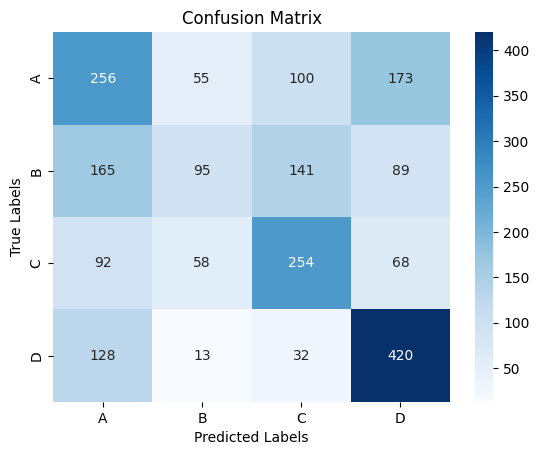

Name:  DHARSANKUMAR R
Register No: 212223240028  
Predicted class: D
Actual class: D


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv('C:\\Users\\admin\\Desktop\\DEEPLEARNING\\customers.csv')


data = data.drop(columns=["ID"])


data.fillna({"Work_Experience": 0, "Family_Size": data["Family_Size"].median()}, inplace=True)


categorical_columns = ["Gender", "Ever_Married", "Graduated", "Profession", "Spending_Score", "Var_1"]
for col in categorical_columns:
    data[col] = LabelEncoder().fit_transform(data[col])


label_encoder = LabelEncoder()
data["Segmentation"] = label_encoder.fit_transform(data["Segmentation"])


X = data.drop(columns=["Segmentation"])
y = data["Segmentation"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

class PeopleClassifier(nn.Module):
    def __init__(self, input_size):
        super(PeopleClassifier, self).__init__()
        
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 4)
        
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        
        x = self.fc3(x)
        return x

def train_model(model, train_loader, criterion, optimizer, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}')

model = PeopleClassifier(input_size=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_model(model, train_loader, criterion, optimizer, epochs=50)

model.eval()
predictions, actuals = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.numpy())
        actuals.extend(y_batch.numpy())

accuracy = accuracy_score(actuals, predictions)
conf_matrix = confusion_matrix(actuals, predictions)
class_report = classification_report(
    actuals,
    predictions,
    target_names=[str(i) for i in label_encoder.classes_]
)

print("Name:          ")
print("Register No:   ")
print(f'Test Accuracy: {accuracy * 100:.2f}%')   # ✅ fixed
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

# Confusion matrix heatmap
sns.heatmap(conf_matrix, annot=True, cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            fmt='g')
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

sample_input = X_test[12].unsqueeze(0)

with torch.no_grad():
    output = model(sample_input)
    predicted_class_index = torch.argmax(output, dim=1).item()
    predicted_class_label = label_encoder.inverse_transform([predicted_class_index])[0]

print("Name:  DHARSANKUMAR R")
print("Register No: 212223240028  ")
print(f'Predicted class: {predicted_class_label}')
print(f'Actual class: {label_encoder.inverse_transform([y_test[12].item()])[0]}')